# Exploratory Data Analysis & Data Cleaning

## Purpose

This notebook focuses on understanding and preparing the Bank Marketing dataset for modeling.  
The goals of this stage are to:

1. Explore the data 
2. Identify and fix data quality issues  
3. Remove potential data leakage  
4. Prepare and save a clean dataset for machine learning  

The cleaned dataset will be saved to the `data/processed/` folder and used in the modeling notebook.

In [43]:
# Import essential libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for cleaner plots
sns.set(style="whitegrid")

In [44]:
# Load the dataset from the raw data folder
# sep=";" is required because the dataset is semicolon-separated
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# Display first 5 rows to understand structure
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [45]:
# Check number of rows and columns
# This tells us dataset size
df.shape

(45211, 17)

In [46]:
# Display column names, data types, and non-null counts
# Helps identify categorical vs numerical features
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [47]:
# Check for missing values
# Important before modeling
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [48]:
# Count number of clients who subscribed vs not subscribed
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [49]:
# Calculate percentage of clients who subscribed vs not subscribed
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

In [50]:
# Calculate percentage distribution of target variable
# This shows class imbalance
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

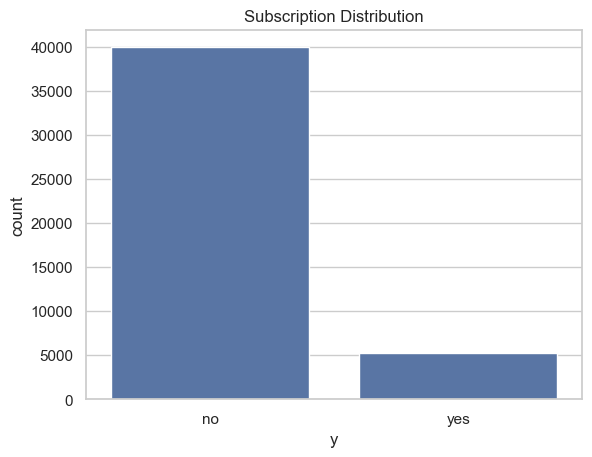

In [51]:
# Visualize target distribution
sns.countplot(x="y", data=df)
plt.title("Subscription Distribution")
plt.show()

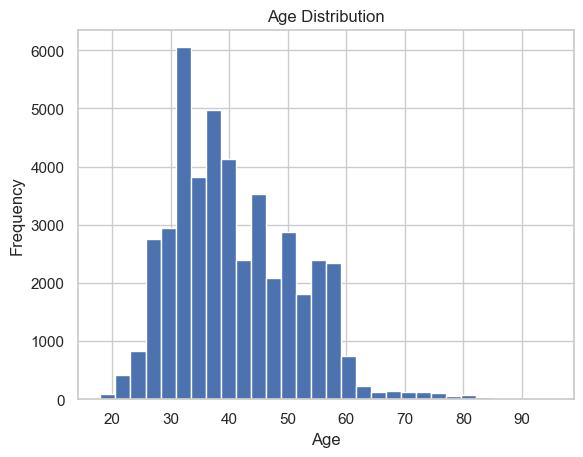

In [52]:
# Plot age distribution
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

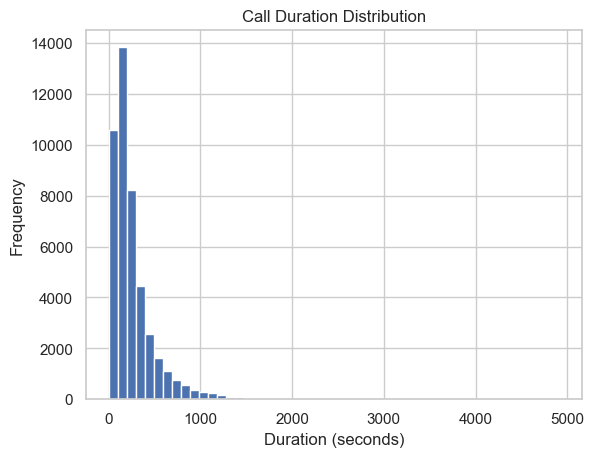

In [53]:
# Plot duration distribution
plt.hist(df["duration"], bins=50)
plt.title("Call Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

In [54]:
# Calculate subscription rate (conversion rate) for each job category
# (s == "yes") creates True/False values, and mean() converts True to 1 and False to 0,
# so the result is the percentage of clients who subscribed in each job group.

df.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y, dtype: float64

In [55]:
# Analyze conversion rate by month
df.groupby("month")["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)

month
mar    0.519916
dec    0.467290
sep    0.464594
oct    0.437669
apr    0.196794
feb    0.166478
aug    0.110133
jun    0.102228
nov    0.101511
jan    0.101212
jul    0.090935
may    0.067195
Name: y, dtype: float64

In [56]:
# Check average duration by subscription outcome
df.groupby("y")["duration"].mean()

y
no     221.182806
yes    537.294574
Name: duration, dtype: float64

Note: duration is much higher for "yes", it indicates leakage risk.

# Fix Data Issues

In [57]:
# Strip whitespace from all object (string) columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

C:\Users\Yenko\AppData\Local\Temp\ipykernel_31980\111344451.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [58]:
# Convert target variable to numeric (0/1)
df["y"] = (df["y"] == "yes").astype(int)

In [59]:
# Drop duplicates if any
df = df.drop_duplicates()

In [60]:
# Remove Data Leakage
# Drop 'duration' column as it is not known before the call and can lead to data leakage
if "duration" in df.columns:
    df = df.drop(columns=["duration"])
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'y'],
      dtype='str')

# Feature Preparation

In [61]:
# Handle Special Value in pdays
# The 'pdays' column has a special value of -1 which indicates that the client was not previously contacted.
# We can replace -1 with a more meaningful value, such as NaN, to indicate missing data for those clients.
if "pdays" in df.columns:
    df["previously_contacted"] = (df["pdays"] != -1).astype(int)

In [62]:
# After creating the 'previously_contacted' column, we can drop the original 'pdays' column as it is no longer needed.
df = df.drop(columns=["pdays"])

In [63]:
# Final check of the cleaned dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   45211 non-null  int64
 1   job                   45211 non-null  str  
 2   marital               45211 non-null  str  
 3   education             45211 non-null  str  
 4   default               45211 non-null  str  
 5   balance               45211 non-null  int64
 6   housing               45211 non-null  str  
 7   loan                  45211 non-null  str  
 8   contact               45211 non-null  str  
 9   day                   45211 non-null  int64
 10  month                 45211 non-null  str  
 11  campaign              45211 non-null  int64
 12  previous              45211 non-null  int64
 13  poutcome              45211 non-null  str  
 14  y                     45211 non-null  int64
 15  previously_contacted  45211 non-null  int64
dtypes: int64(7), st

In [64]:
# Quick preview of the cleaned dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,y,previously_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,unknown,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,unknown,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,unknown,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,unknown,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,unknown,0,0


In [65]:
#Save cleaned dataset
df.to_csv("../data/processed/bank_cleaned.csv", index=False)

As a result of this data cleaning activity, the following changes were implemented:
- Removed duration (leakage)
- Converted y to 0/1
- Stripped whitespace
- Removed duplicates
- Created previously_contacted
- Saved cleaned dataset